# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# завантажити
df = pd.read_csv("../data/House_Rent_Dataset.csv")

In [3]:
# розмір
df.shape

(4746, 12)

In [4]:
# хед
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [5]:
# заг інф
df.info


<bound method DataFrame.info of        Posted On  BHK   Rent  Size            Floor    Area Type  \
0     2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1     2022-05-13    2  20000   800       1 out of 3   Super Area   
2     2022-05-16    2  17000  1000       1 out of 3   Super Area   
3     2022-07-04    2  10000   800       1 out of 2   Super Area   
4     2022-05-09    2   7500   850       1 out of 2  Carpet Area   
...          ...  ...    ...   ...              ...          ...   
4741  2022-05-18    2  15000  1000       3 out of 5  Carpet Area   
4742  2022-05-15    3  29000  2000       1 out of 4   Super Area   
4743  2022-07-10    3  35000  1750       3 out of 5  Carpet Area   
4744  2022-07-06    3  45000  1500     23 out of 34  Carpet Area   
4745  2022-05-04    2  15000  1000       4 out of 5  Carpet Area   

                 Area Locality       City Furnishing Status  Tenant Preferred  \
0                       Bandel    Kolkata       Unfurnished  Bachelors

## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [6]:
# Аналіз пропущених значень
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) *100
missing_percent

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64

не виявили пропусків даних, тому очищення чи видалення рядків не потребуємо

In [7]:
# Базова статистика

stats = df.describe()
stats.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


статистика показує 

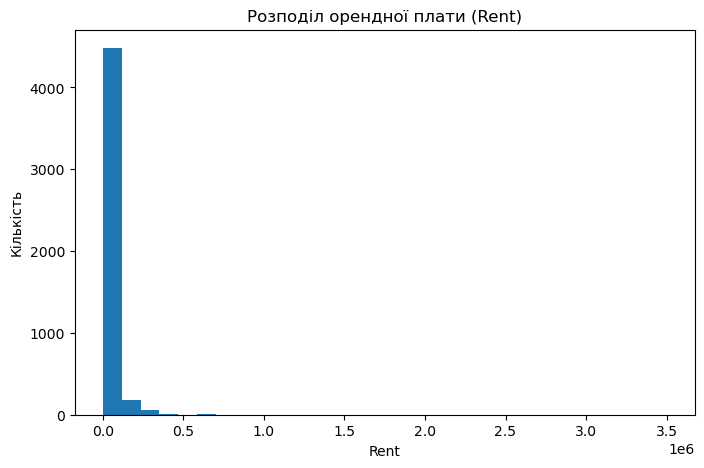

In [8]:
# Аналіз цільової змінної Rent

plt.figure(figsize=(8,5))
df["Rent"].plot(kind="hist", bins=30)

plt.title("Розподіл орендної плати (Rent)")
plt.xlabel("Rent")
plt.ylabel("Кількість")
plt.show()

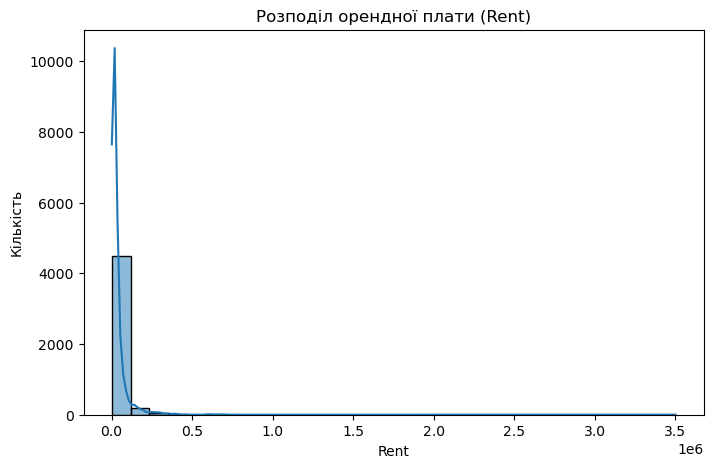

In [9]:
# або

plt.figure(figsize=(8, 5))
sns.histplot(df["Rent"], bins=30, kde=True)

plt.title("Розподіл орендної плати (Rent)")
plt.xlabel("Rent")
plt.ylabel("Кількість")
plt.show()

Ми отримали сильно скошений вправо розподіл - більшість значень потрапляють в діапазон низької оренди, але є невелика кількість дорогих обʼєктів (наші викиди). Тож нам знадобиться додаткова обробка даних.

In [10]:
# Робота з викидами
# межі

Q1 = df["Rent"].quantile(0.25)  # 25% даних дешевші за це значення
Q3 = df["Rent"].quantile(0.75)  # 75% даних дешевші за це значення
IQR = Q3 - Q1                   # основна маса

# межі нормальних значень
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"lower_bound = {lower_bound}, upper_bound = {upper_bound}")

lower_bound = -24500.0, upper_bound = 67500.0


In [11]:
# фільтруємо, видаляємо викиди

df_clean = df[(df["Rent"] >= lower_bound) & (df["Rent"] <= upper_bound)].copy()

In [12]:
# перевірка

df.shape, df_clean.shape

((4746, 12), (4226, 12))

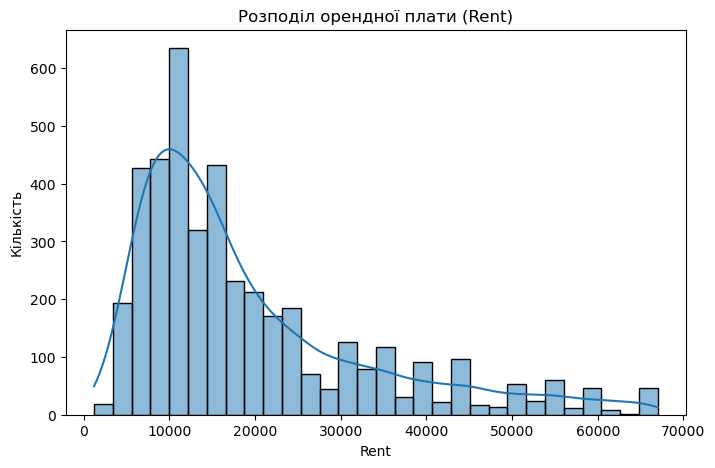

In [13]:
# новий шрафік

plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Rent"], bins=30, kde=True)

plt.title("Розподіл орендної плати (Rent)")
plt.xlabel("Rent")
plt.ylabel("Кількість")
plt.show()

IQR — основна маса. Значення які виходять за нижню та верхню границі були видалені.

Ми залишили тільки адекватні значення Rent (видалили близько 520рядків)

Ми також отримали lower_bound = -24500, але рента не може бути відємною, тому нам важлива саме верхня межа upper_bound = 67500 - все що вище цього значення буде відкинуто.

Так ми зробили дані приатними для подальшого аналіізу.


In [14]:
# створюєм нову колонку, де великі значення стиснуті
# log1p(x) = log(1 + x) безпечніше, навіть якщо раптом трапиться 0.

df_clean["log_Rent"] = np.log1p(df_clean["Rent"])

In [15]:
df_clean.describe().round(2)

,BHK,Rent,Size,Bathroom,log_Rent
count,4226.00,4226.00,4226.00,4226.00,4226.00
mean,1.96,19286.16,871.78,1.81,9.64
std,0.75,13825.40,485.78,0.71,0.66
min,1.00,1200.00,10.00,1.00,7.09
25%,1.00,9500.00,520.00,1.00,9.16
50%,2.00,15000.00,800.00,2.00,9.62
75%,2.00,25000.00,1100.00,2.00,10.13
max,6.00,67000.00,4200.00,7.00,11.11


Застосування логарифмування дозволяє зменшити асиметрію розподілу, та вплив великих значень. Це покращить якість лінійної можелі

До очищення було:

Rent max = 3 500 000
mean ≈ 34 993

Після:

Rent max = 67 000
mean ≈ 19 286
median = 15 000

Без екстремальних значень, навчаємо модель саме на типових спостереженнях

In [16]:
# Аналіз категоріальних змінних

category_columns = df_clean.select_dtypes(include="object").columns
df_clean[category_columns].nunique().sort_values(ascending=False)


Area Locality        1997
Floor                 340
Posted On              80
City                    6
Area Type               3
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
dtype: int64

Area Locality, Floor та дату відкидаємо, інші колонки перетворюємо:

In [17]:
category_columns = ["City", "Area Type", "Furnishing Status",  "Tenant Preferred", "Point of Contact"]

In [18]:
df_encoded = pd.get_dummies(df_clean, columns=category_columns, drop_first=True)

До моделі включили лише ті змінні, які мають невелику кількість унікальних значень (City, Area Type, Furnishing Status, Tenant Preferred, Point of Contact), Інші відкинули


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [19]:
# матриця кореляцій

numbers_df = df_clean.select_dtypes(include=["number"])   # взяти числа

correlation_matrix = numbers_df.corr().round(3)                      
correlation_matrix

,BHK,Rent,Size,Bathroom,log_Rent
BHK,1.000,0.401,0.698,0.748,0.465
Rent,0.401,1.000,0.394,0.507,0.937
Size,0.698,0.394,1.000,0.681,0.447
Bathroom,0.748,0.507,0.681,1.000,0.561
log_Rent,0.465,0.937,0.447,0.561,1.000


In [20]:
# кореляційнa матриця - heatmap

fig = px.imshow(
    correlation_matrix,
    text_auto = ".2f",
    color_continuous_scale= "RdBu_r",
    title = "Кореляційна матриця",
    labels = dict(color = "Кореляція")
)
fig.update_layout(height=500)
fig.show()

In [21]:
# Інтерпретація кореляції

# 0.7-1.0 — сильна позитивна кореляція
# 0.3-0.7 — помірна позитивна кореляція
# -0.3-0.3 — слабка або відсутня кореляція
# -0.7--0.3 — помірна негативна кореляція
# -1.0--0.7 — сильна негативна кореляція

Як видно, ми маємо:

сидьну кореляцію 

0.75 між BHK та Bathroom, 

і 0.7 між BHK та Size.

та досить сильну позитивну кореляцію 0.68 між Size та Bathroom.

помірно позитивну 

0.51 між Bathroom та Rent,

0.4 між BHK та Rent

0.39 між Size та Rent

Загалом, між змінними BHK, Size та Bathroom спостерігаємо високу кореляцію, це потребує подальшої уваги.

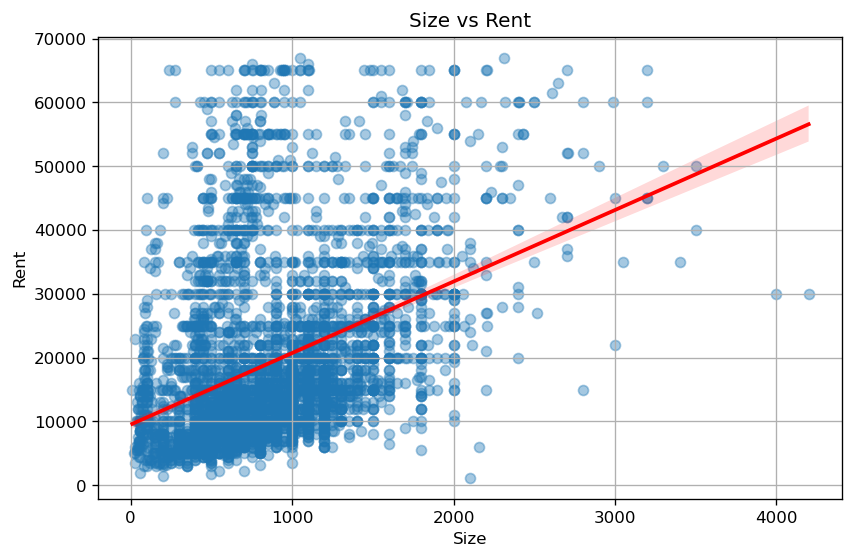

In [22]:
# scatter plot між Size та Rent

plt.figure(figsize=(8, 5), dpi = 120)

sns.regplot(
    data = df_clean, 
    x= "Size", 
    y= "Rent", 
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Size vs Rent")
plt.xlabel("Size")
plt.ylabel("Rent")
plt.grid("True")

plt.show()

лінія тренду вказує позитивну залежність між Size та Rent.
Зі збільшенням площі зростає і вартість оренди.
Видно також що для більших площ наявний і більший розкид значень, це свідчить про вплив інших факторів, наприклад локації


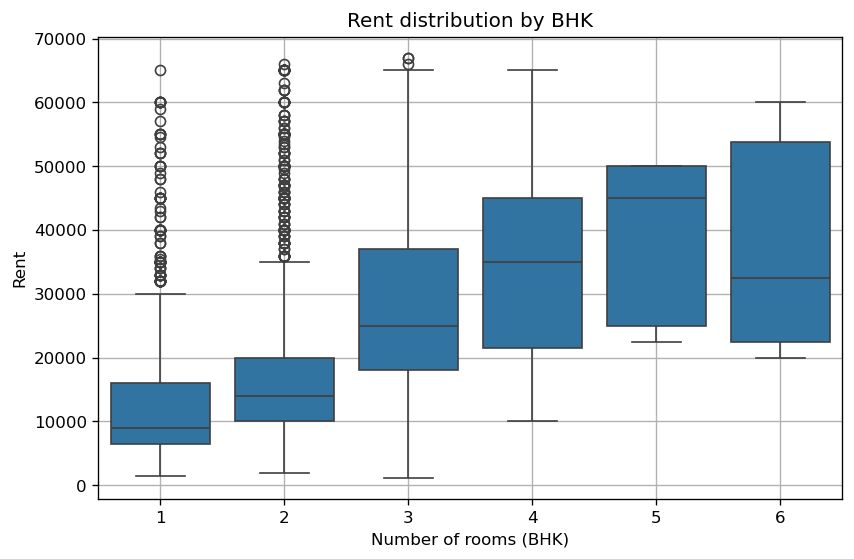

In [23]:
# взаємозв'язок між BHK та Rent за допомогою boxplot

plt.figure(figsize=(8, 5), dpi = 120)

sns.boxplot(
    data = df_clean.sort_values("BHK"),
    x = "BHK",
    y = "Rent"
)

plt.title("Rent distribution by BHK")
plt.xlabel("Number of rooms (BHK)")
plt.ylabel("Rent")
plt.grid(True)

plt.show()

Boxplot показує чіткий позитивний зв’язок між кількістю кімнат та орендною платою. Зі збільшенням ВНК зростає і оренда, збільшується розкид цін - більша квартира, більша варіативність ціни. Для маленьких квартир спостерігаємо багато викидів - трапляються дорогі варіанти навіть з малими площами.

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [24]:
# One-Hot Encoding

category_columns = df_clean.select_dtypes(include="object").columns

df_clean[category_columns].nunique().sort_values(ascending=False)

Area Locality        1997
Floor                 340
Posted On              80
City                    6
Area Type               3
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
dtype: int64

In [25]:
category_columns  = ["City", "Area Type", "Furnishing Status", "Tenant Preferred", "Point of Contact"]

df_model = pd.get_dummies(df_clean, columns=category_columns, drop_first=True)

In [26]:
# не берем в модель\видаляєм

drop_columns = ["Posted On", "Area Locality", "Floor"]

До моделі включили лише ті змінні, які мають невелику кількість унікальних значень (City, Area Type, Furnishing Status, Tenant Preferred, Point of Contact), для них застосовано One-Hot Encoding, Інші відкинули

In [27]:
# ділимо дані на ознаки (X) та цільову змінну (y)

# цільова змінна: що будемо прогнозувати
y = df_model["log_Rent"]

# ознаки:    на основі чого будемо прогнозувати 
X = df_model.drop(columns=["Rent", "log_Rent"] + drop_columns)

In [28]:
# стандартизація:

num_columns = X.select_dtypes(include=["int64", "float64"]).columns

In [29]:
X.shape, y.shape

((4226, 16), (4226,))

In [30]:
X.head()

,BHK,Size,Bathroom,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Area Type_Carpet Area,Area Type_Super Area,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner
0,2,1100,2,False,False,False,True,False,False,True,False,True,True,False,False,True
1,2,800,1,False,False,False,True,False,False,True,True,False,True,False,False,True
2,2,1000,1,False,False,False,True,False,False,True,True,False,True,False,False,True
3,2,800,1,False,False,False,True,False,False,True,False,True,True,False,False,True
4,2,850,1,False,False,False,True,False,True,False,False,True,False,False,False,True


зробимо стандартизацію після train/test split (нижче) аби навчання відбулось лише на тренувальних даних

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
# ділимо на навчальну і тестову вибірки

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# StandardScaler

from sklearn.preprocessing import StandardScaler

In [34]:
scaler = StandardScaler()

num_columns = X.select_dtypes(include=["int64", "float64"]).columns

# fit_transform тільки на train
X_train[num_columns] = scaler.fit_transform(X_train[num_columns])

# transform на test
X_test[num_columns] = scaler.transform(X_test[num_columns])

In [35]:
# LinearRegression

from sklearn.linear_model import LinearRegression

In [36]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
# коефіцієнти моделі:
# model.coef_ = вага ознаки
# index=X.columns => привязуємо коеф до кололнок

coefficients = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
coefficients.head(15)

# так побачимо табл впливу ознак

City_Mumbai                          0.828994
Size                                 0.180549
BHK                                  0.159638
Area Type_Carpet Area                0.147747
City_Delhi                           0.122773
Area Type_Super Area                 0.121975
Bathroom                             0.093230
City_Chennai                        -0.038977
Tenant Preferred_Bachelors/Family   -0.048490
Tenant Preferred_Family             -0.081107
City_Hyderabad                      -0.114654
Furnishing Status_Semi-Furnished    -0.156857
Furnishing Status_Unfurnished       -0.267289
City_Kolkata                        -0.272719
Point of Contact_Contact Owner      -0.339668
dtype: float64

In [38]:
# ознаки які найбільше впливають на прогноз (сила впливу = по модулю!)

coefficients_abs = coefficients.abs().sort_values(ascending=False)
coefficients_abs.head(15)

City_Mumbai                          0.828994
Point of Contact_Contact Builder     0.511146
Point of Contact_Contact Owner       0.339668
City_Kolkata                         0.272719
Furnishing Status_Unfurnished        0.267289
Size                                 0.180549
BHK                                  0.159638
Furnishing Status_Semi-Furnished     0.156857
Area Type_Carpet Area                0.147747
City_Delhi                           0.122773
Area Type_Super Area                 0.121975
City_Hyderabad                       0.114654
Bathroom                             0.093230
Tenant Preferred_Family              0.081107
Tenant Preferred_Bachelors/Family    0.048490
dtype: float64

Як видно найсильніший вплив на прогноз має ознака City_Mumbai = 0.83 дуже високий коефіцієнт, сильно виділяється зпоміж інших. Виходить що квартира в Мумбаі буде значно дорожчою порівняно з базовою локацією. Отже, розашування формує орендну плату.
А от другий за вагомістю фактор - Point of Contact_Contact Builder = 0.52 складно інтерпретувати. Можливо йдеться про доступність орендодавця, легкість спілкування, довіру.
Тому візьмемо до уваги наступні показники - Furnishing Status_Unfurnished = -0.267289 має значний негативний вплив, житло без меблювання асоціюється із нижчою орендною платою. 
Тоді як ознаки Size = 0.18 та BHK = 0.16 підтверджують що більша площа та більша кількість кімнат підвищують прогнозовану орендну плату, що відповідає звичайній логіці.

In [39]:
# прогноз

# на навч вибірці
y_train_predict = model.predict(X_train)

# на тестовій вибірці
y_test_predict = model.predict(X_test)

In [40]:
# поріівняймо (тут log_Rent)

comparison = pd.DataFrame({
    "Rent": y_test.iloc[:10],
    "Predicted_Rent": y_test_predict[:10].round(0),
    "Error": (y_test.iloc[:10] - y_test_predict[:10].round(0))
})
comparison = comparison.reset_index(drop=True)

#print("Приклади прогнозів на тестовій вибірці:")
print(comparison)

        Rent  Predicted_Rent     Error
0   9.998843            10.0 -0.001157
1   8.517393             9.0 -0.482607
2  10.518700            11.0 -0.481300
3   8.987322             9.0 -0.012678
4   9.615872            10.0 -0.384128
5   9.903538            10.0 -0.096462
6   9.047939             9.0  0.047939
7   8.853808             9.0 -0.146192
8   8.006701             9.0 -0.993299
9   8.987322             9.0 -0.012678


In [41]:
# поріівняймо (тут реальні ціни)

real = np.expm1(y_test.iloc[:10])
pred = np.expm1(y_test_predict[:10])

comparison_real = pd.DataFrame({
    "Real_Rent": real.round(0),
    "Predicted_Rent": pred.round(0),
    "Error": (real - pred).round(0)
})
comparison_real = comparison_real.reset_index(drop=True)

print("Приклади прогнозів на тестовій вибірці:")
print(comparison_real)

Приклади прогнозів на тестовій вибірці:
   Real_Rent  Predicted_Rent   Error
0    22000.0         26007.0 -4007.0
1     5000.0          6912.0 -1912.0
2    37000.0         45100.0 -8100.0
3     8000.0          6653.0  1347.0
4    15000.0         13415.0  1585.0
5    20000.0         21890.0 -1890.0
6     8500.0         13249.0 -4749.0
7     7000.0          6585.0   415.0
8     3000.0          5172.0 -2172.0
9     8000.0          7842.0   158.0


In [42]:
# від’ємна помилка = модель завищила прогноз
# додатна помилка = модель занизила прогноз

Приклади прогнозів на тестовій вибірці загалом відповідають величині орендної плати, але зустрічаються також і помітні помилки. Тобто модель працююча, але ще не точна.

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
# MAE (Mean Absolute Error) - Середня абсолютна помилка
# Інтерпретація: Середня помилка прогнозу в одиницях цільової змінної. 
# Наприклад, MAE = 50 означає, що в середньому ми помиляємось на 50 лайків.

# тестова вибірка
mae_test = mean_absolute_error(y_test, y_test_predict)

# навчальна вибірка
mae_train = mean_absolute_error(y_train, y_train_predict)

In [45]:
# RMSE (Root Mean Squared Error) - Корінь середньоквадратичної помилки
# Інтерпретація: Схоже на MAE, але більше "карає" за великі помилки через піднесення до квадрату.

# тестова вибірка
mse_test = mean_squared_error(y_test, y_test_predict)
rmse_test = np.sqrt(mse_test)

# навчальна вибірка
mse_train = mean_squared_error(y_train, y_train_predict)
rmse_train = np.sqrt(mse_train)

In [46]:
# R² (Coefficient of Determination) - Коефіцієнт детермінації
# Інтерпретація:
# Показує, яку частку варіації в даних пояснює модель
# Значення від 0 до 1 (може бути негативним для дуже поганих моделей)
# R² = 0.7 означає, що модель пояснює 70% варіації в даних

# тестова вибірка
r2_test = r2_score(y_test, y_test_predict)

# навчальна вибірка
r2_train = r2_score(y_train, y_train_predict)

In [47]:
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):")
print(f"\nMAE: {mae_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"R²: {r2_test:.3f}")

print()
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:")
print(f"\nMAE: {mae_train:.2f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"R²: {r2_train:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):

MAE: 0.28
RMSE: 0.36
R²: 0.721

МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:

MAE: 0.27
RMSE: 0.36
R²: 0.706


In [48]:
# переводимо в реальні гроші (після log_Rent)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_predict)

mae_real = mean_absolute_error(y_test_real, y_test_pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_test_pred_real))

print(f"MAE (real): {mae_real:.0f}")
print(f"RMSE (real): {rmse_real:.0f}")

MAE (real): 5360
RMSE (real): 8900


In [49]:
# а на навчальній. вибірці

y_train_real = np.expm1(y_train)
y_train_pred_real = np.expm1(y_train_predict)

mae_train_real = mean_absolute_error(y_train_real, y_train_pred_real)
rmse_train_real = np.sqrt(mean_squared_error(y_train_real, y_train_pred_real))

print(f"MAE (real): {mae_train_real:.0f}")
print(f"RMSE (real): {rmse_train_real:.0f}")

MAE (real): 5162
RMSE (real): 8285


Порівняймо Train і Test :

MAE: 0.27 і 0.28 майже однакові

RMSE: рівні

R²_test= 0.721  > R²_train =0.706

такі близькі показники говорять про однакову якість, отже і відсутність перенавчання.

Високе значення R² = модель враховує основні фактори, що впливають на оренду.


Порівняймо після переведення на реальні гроші (після log_Rent) :

тестова:

MAE (real): 5360

RMSE (real): 8900

навчальна:

MAE (real): 5162

RMSE (real): 8285

Модель помиляється в середньому на 5360, але трапляються і великі помилки у 8900. Але і наш розкид цін на ринку дуже суттєвий, тому навіть такі помилки можуть бути нормою.


Оскільки тестові і навчальні розрахунки дуже близьки, наша модель добре узагальнює дані та не показує схильності до перенавчання чи недонавчання.

In [50]:
# спочатку перейдем від log до real
y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_predict)

# графік розсіювання "реальні vs прогнозовані значення" 
fig = px.scatter(
    x = y_test_real,
    y = y_test_pred_real,
    title = "реальні vs прогнозовані значення (тестова вибірка)",
    labels = {
        "x": "Реальна вартість оренди",
        "y": "Прогнозована вартість оренди"
    } ,
    opacity = 0.6
)

# лінія ідеального прогнозу
max_val = max(y_test_real.max(), y_test_pred_real.max())
fig.add_trace(
    go.Scatter(
        x=[0, max_val],
        y=[0, max_val],
        mode= "lines",
        name= "Ідеальний прогноз",
        line = dict(color="red", dash="dash")
    )
)

fig.update_layout(height=500)
fig.show()

In [ ]:
# Інтерпретація графіку:
# Точки на червоній лінії — ідеальний прогноз
# Точки вище лінії — модель переоцінює (прогноз > реальність)
# Точки нижче лінії — модель недооцінює (прогноз < реальність)
# Розкид точок — показує точність моделі

На графіку точки слідують за лінією ідеального прогнозущо свідчить про здатність моделі вловлювати загальну залежність між ознаками та орендною платою. Водночас спостерігається помітний розкид точок, особливо для об’єктів з вищою вартістю оренди. Отже, модель добре відтворює загальну тенденцію, але для окремих об’єктів дає суттєві похибки.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [51]:
# помилки (залишки):

residuals = y_test_real - y_test_pred_real      # на реальних грошах

# гістограма розподілу помилок
fig = px.histogram(
    x = residuals,
    nbins = 50,
    title = "Розподіл помилок прогнозування",
    labels = {
        "x": "Помилка (реальні - прогнозовані)", 
        "count": "Кількість"
    },
    color_discrete_sequence = ["#e74c3c"]
)

fig.add_vline(x = 0, line_dash = "dash", line_color = "black", annotation_text = "Ідеальний прогноз")
fig.update_layout(height=400)
fig.show()

In [ ]:
# Статистика помилок:
# Середня помилка близька до 0 — модель не має систематичної похибки
# Великі відхилення — модель помиляється на дорогих обʼєктах
# Симетричний розподіл — модель однаково часто завищує та занижує

Середня помилка у нас центрована близько 0, тобто нема сисематичної помилки. Форма дзвону каже що помилки не систематичні, випадкові. А от лівий хвіст до -80к це завищений прогноз, показує сильну переоцінку дорогих обєктів

In [52]:
# пошук обʼєктів з найбільшими помилками

errors_df = pd.DataFrame({
    "real": y_test_real.values,     # на реальних грошах
    "predicted": y_test_pred_real,
    "error": np.abs(residuals)
})

# рахуємо помилку тут для уникнення зсуву по індексах
errors_df["error"] = np.abs(errors_df["real"] - errors_df["predicted"])

# топ5 помилок
top_errors = errors_df.nlargest(5, "error")

print("Обʼєкти з найбільшими помилками прогнозування:")
print(top_errors)

Обʼєкти з найбільшими помилками прогнозування:
         real      predicted         error
4350  60000.0  135864.651365  75864.651365
275   30000.0   97910.100876  67910.100876
4409  50000.0   98047.025468  48047.025468
1124  57000.0  102134.689214  45134.689214
809   60000.0   24682.073654  35317.926346


У випадках високої вартості оренди виникають суттʼві помилки - модель сильно переоцінює ці обʼєкти, мабуть не вдається врахувати важливі характеристики, наприклад локації. 

In [53]:
# на яких типах житла модель помиляється найбільше


# збираєм в табл реальну вартість, прогноз, помилку, місто і к-сть кімнат
errors_simple = pd.DataFrame({
    "real_rent": y_test_real,
    "pred_rent": y_test_pred_real,
    "BHK": df_clean.loc[y_test.index, "BHK"],
    "City": df_clean.loc[y_test.index, "City"]
})

errors_simple["abs_error"] = abs(errors_simple["real_rent"] - errors_simple["pred_rent"])
errors_simple.head()

,real_rent,pred_rent,BHK,City,abs_error
1998,22000.0,26007.286031,3,Bangalore,4007.286031
3190,5000.0,6911.548415,1,Chennai,1911.548415
2670,37000.0,45099.633849,3,Delhi,8099.633849
4647,8000.0,6652.574233,1,Hyderabad,1347.425767
4488,15000.0,13414.814417,2,Hyderabad,1585.185583


In [54]:
# cередня помилка по BHK

errors_simple.groupby("BHK")["abs_error"].mean().sort_values(ascending=False)

BHK
6    52048.937092
5    48047.025468
4    16237.351134
3     7913.792138
2     4639.456018
1     3643.082538
Name: abs_error, dtype: float64

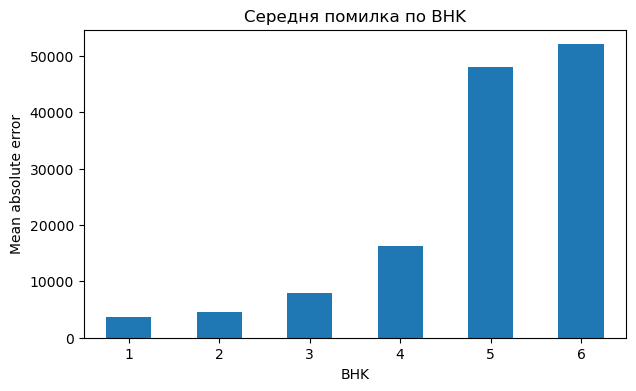

In [55]:
errors_simple.groupby("BHK")["abs_error"].mean().plot(kind="bar", figsize=(7,4), title="Середня помилка по BHK")

plt.ylabel("Mean absolute error")
plt.xticks(rotation=0)
plt.show()

In [56]:
# cередня помилка по City

errors_simple.groupby("City")["abs_error"].mean().sort_values(ascending=False)

City
Mumbai       10068.064781
Delhi         7110.355647
Hyderabad     4950.645292
Chennai       4324.738490
Bangalore     3759.327621
Kolkata       3356.811783
Name: abs_error, dtype: float64

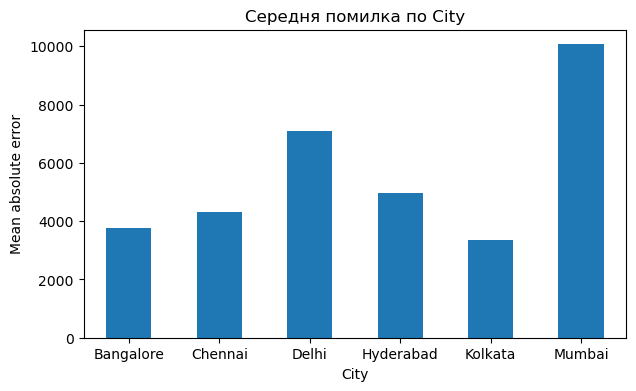

In [57]:
errors_simple.groupby("City")["abs_error"].mean().plot(kind="bar", figsize=(7,4), title="Середня помилка по City")

plt.ylabel("Mean absolute error")
plt.xticks(rotation=0)
plt.show()

Отже, найбільше помилок наша модель робить 5-6 кімнатних квартир, та житла розташованого в містах Mumbai та Delhi.

Мабуть, саме великий розкид вартості оренди для такого типу житла призводить до цих помилок. Ця проста лінійна модель не справляється з нюансами прогнозування таких обʼєктів

Покращити нашу модель могли б прибравши деяякі дивні ознаки - як Point of Contact, яка давала дуже сильний вплив, але невідомо чому і неінформативно для нас.